In [146]:
import nltk.corpus
from collections import Counter
from typing import List
import stopwordsiso as stopwords # Multilangual as opposed to nltk stopwords
from nltk.corpus import stopwords as stopwords_nltk
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import math

nltk.download('brown')
nltk.download('indian')

brown = nltk.corpus.brown
indian = nltk.corpus.indian
stop_words_in = stopwords.stopwords(["hi", "te"])
stopwords_en = set(stopwords_nltk.words('english'))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package brown to
[nltk_data]     /Users/jadenvanrijswijk/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package indian to
[nltk_data]     /Users/jadenvanrijswijk/nltk_data...
[nltk_data]   Package indian is already up-to-date!


In [152]:
# Step 1
def common_words(words: List[str], n: int, corpus_name: str = "") -> List[str]:
    if corpus_name == 'indian':
        words = [w.lower() for w in words if w.isalnum()] # Lower alphanumeric
        words = [w for w in words if w not in stop_words_in] # No stopwords
    else:
        words = [w.lower() for w in words if w.isalpha()] # Lower aplha
        words = [w for w in words if w not in stopwords_en] # No stopwords
        words = [lemmatizer.lemmatize(w) for w in words] # Lemmatize
    freq_words = Counter(words)
    commons = freq_words.most_common()
    return commons[:n]

commons_brown = common_words(brown.words(), 10)
commons_religion = common_words(brown.words(categories='religion'), 10)
commons_mystery = common_words(brown.words(categories='mystery'), 10)

print(commons_brown) # i
# ii
print(commons_religion) 
print(commons_mystery)


[('one', 3408), ('would', 2714), ('said', 1961), ('time', 1898), ('new', 1635), ('year', 1608), ('could', 1601), ('may', 1415), ('two', 1414), ('state', 1410)]
[('god', 138), ('church', 127), ('one', 110), ('new', 99), ('world', 95), ('may', 79), ('spirit', 71), ('would', 69), ('man', 68), ('life', 62)]
[('said', 204), ('would', 189), ('one', 182), ('back', 159), ('could', 145), ('like', 139), ('man', 107), ('get', 105), ('know', 93), ('two', 89)]


In [123]:
# Step 2
def extract_insights(corpus, category=None, language=None):
    if category is not None:
        words = corpus.words(categories=category)
        sents = corpus.sents(categories=category)
    elif language is not None:
        words = corpus.words(language + '.pos')
        sents = corpus.sents(language + '.pos')
    else:
        words = corpus.words()
        sents = corpus.sents()
        
    n_tokens = len(words) # i
    n_types = len(set(words)) # ii
    word_list = [w.lower() for w in words if w.isalpha()] # iii
    sent_lengths = [len([w for w in s if w.isalpha()]) for s in sents]
    avg_words_sent = sum(sent_lengths) / len(sent_lengths) # iv
    avg_word_len = sum(len(w) for w in words) / len(words) # v
    if corpus == brown:
        lemmas = [lemmatizer.lemmatize(w) for w in word_list]
        n_lemmas = len(set(lemmas)) # vi
    else:
        n_lemmas = "N/A"
    
    print(f"Corpus: {category if category else 'All'}, Language: {language if language else 'N/A'}")
    print(f"Number of tokens: {n_tokens}\n Number of types: {n_types}\n Average words per sentence: {avg_words_sent:.2f}\n Average word length: {avg_word_len:.2f}\n Number of lemmas: {n_lemmas}\n")

extract_insights(brown)
extract_insights(brown, category='religion')
extract_insights(brown, category='mystery')

Corpus: All, Language: N/A
Number of tokens: 1161192
 Number of types: 56057
 Average words per sentence: 17.12
 Average word length: 4.28
 Number of lemmas: 34998

Corpus: religion, Language: N/A
Number of tokens: 39399
 Number of types: 6373
 Average words per sentence: 19.79
 Average word length: 4.28
 Number of lemmas: 5042

Corpus: mystery, Language: N/A
Number of tokens: 57169
 Number of types: 6982
 Average words per sentence: 11.99
 Average word length: 3.80
 Number of lemmas: 5556



In [124]:
# Step 3
tag_freqs = Counter([p[1] for p in brown.tagged_words()])
print(tag_freqs.most_common(10))

[('NN', 152470), ('IN', 120557), ('AT', 97959), ('JJ', 64028), ('.', 60638), (',', 58156), ('NNS', 55110), ('CC', 37718), ('RB', 36464), ('NP', 34476)]


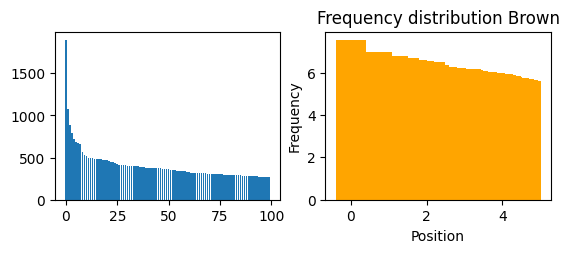

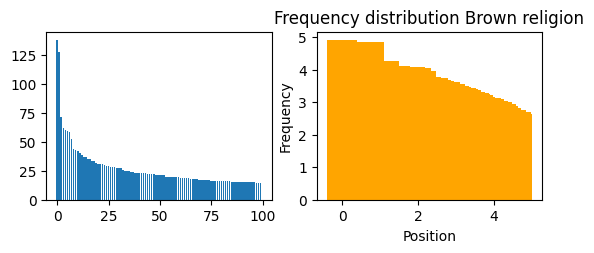

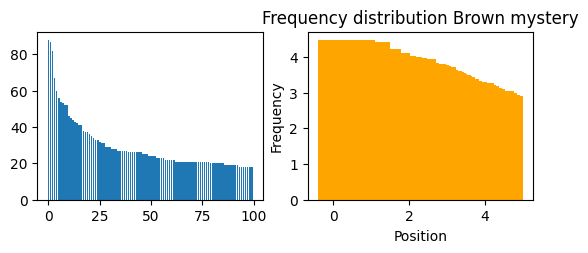

In [125]:
# Step 4
def plot_frequency_distribution(commons, suffix=''):
    words, freqs = zip(*commons)
    indices = range(len(words))
    log_freqs = [math.log(freq) for freq in freqs]
    log_indices = [math.log(i+1) for i in indices]
    
    plt.subplot(2, 2, 1)
    plt.bar(indices, freqs)
    plt.subplot(2, 2, 2)
    plt.bar(log_indices, log_freqs, color='orange')
    
    plt.xlabel('Position')
    plt.ylabel('Frequency')
    plt.title(f'Frequency distribution {suffix}')
    plt.show()
    
plot_frequency_distribution(commons_brown, 'Brown')
plot_frequency_distribution(commons_religion, 'Brown religion')
plot_frequency_distribution(commons_mystery, 'Brown mystery')

[('.', 2195), (',', 1444), ('৷', 840), ('।', 493), ('आहे', 406), ('"', 221), ("'", 182), ('आणि', 155), ('না', 122), ('ఈ', 112)] [('।', 493), (',', 96), ('विकेट', 69), ('रन', 60), ('पाकिस्तान', 39), ('रनों', 39), ('पारी', 36), ('गई', 26), ('सरकार', 24), ('भारत', 23)] [('.', 994), (',', 415), ('ఈ', 112), ('ఆ', 93), ('ఆడిట్', 89), ('లో', 79), ('ఒక', 56), ('రాజనీతి', 56), ('జంతువు', 55), ('పని', 44)]
Corpus: All, Language: N/A
Number of tokens: 48754
 Number of types: 16143
 Average words per sentence: 0.76
 Average word length: 4.97
 Number of lemmas: N/A

Corpus: All, Language: hindi
Number of tokens: 9408
 Number of types: 2186
 Average words per sentence: 1.82
 Average word length: 3.85
 Number of lemmas: N/A

Corpus: All, Language: telugu
Number of tokens: 9999
 Number of types: 4209
 Average words per sentence: 0.40
 Average word length: 5.84
 Number of lemmas: N/A

[('PREP', 1921), ('NN', 1775), ('NNP', 776), ('VFM', 738), ('PUNC', 559), ('VAUX', 519), ('QFNUM', 447), ('PRP', 363), 

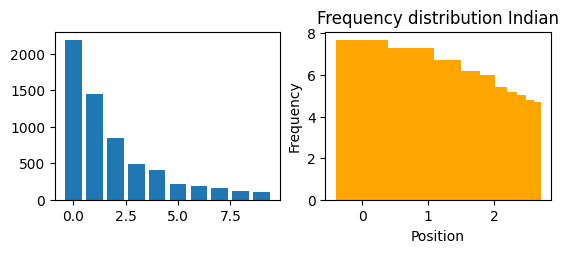

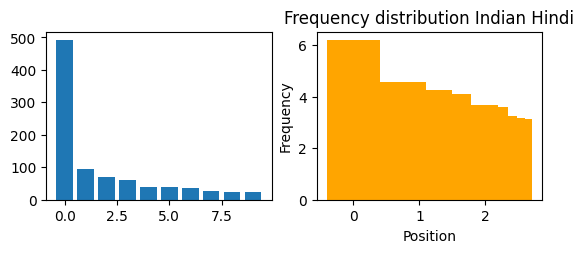

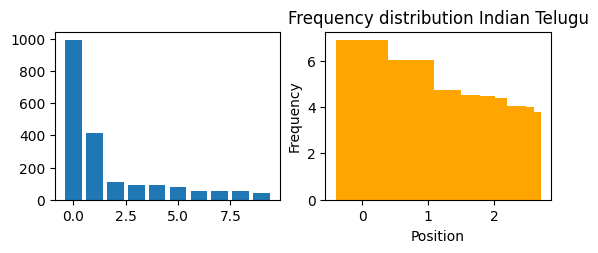

In [150]:
# Step 5 Repeat for the Indian corpus

# 5.1 
commons_indian = common_words(indian.words(), 10, corpus_name='indian')
commons_hindi = common_words(indian.words('hindi.pos'), 10, corpus_name='indian')
commons_telugu = common_words(indian.words('telugu.pos'), 10, corpus_name='indian')
print(commons_indian, commons_hindi, commons_telugu)

# 5.2
extract_insights(indian)
extract_insights(indian, language='hindi')
extract_insights(indian, language='telugu')

# 5.3
tag_freqs_hindi = Counter([p[1] for p in indian.tagged_words('hindi.pos')])
print(tag_freqs_hindi.most_common(10))

# 5.4
plot_frequency_distribution(commons_indian, 'Indian')
plot_frequency_distribution(commons_hindi, 'Indian Hindi')
plot_frequency_distribution(commons_telugu, 'Indian Telugu')

